# LAB 2: Rhythm

Summary:
1. Rhythm Analysis
2. Time Function

**Please do NOT use any AI assistant to answer the questions in this lab**, as it is meant to be a practical exercise for you to learn how to manipulate musical data in Python. You can be asked to explain your code as part of the grading process, so make sure you understand what you are doing.

This lab is graded. The deadline for submission is March 16.

If you have any questions or need help, feel free to ask the TAs. 

In [25]:
import mido
import matplotlib.pyplot as plt
import numpy as np
import ms3
from music21 import converter
from collections import Counter

midi_file_path = 'res/midi_score.mid'
performance_midi_file_path = 'res/Zhou01M.mid'

## Part 1: Rhythm Analysis

In [32]:
path_to_corpus = "../lab_2/ABC-main/" # TODO: change this to the path where you downloaded the corpus

notes = ms3.load_tsv(path_to_corpus + "notes/n01op18-1_04.notes.tsv")
notes

,mc,mn,quarterbeats,quarterbeats_all_endings,duration_qb,mc_onset,mn_onset,timesig,staff,voice,duration,gracenote,nominal_duration,scalar,tied,tpc,midi,name,octave,chord_id
0,1,1,0,0,0.166667,0,0,2/4,1,1,1/24,<NA>,1/16,2/3,<NA>,-1,77,F5,5,0
1,1,1,1/6,1/6,0.166667,1/24,1/24,2/4,1,1,1/24,<NA>,1/16,2/3,<NA>,4,76,E5,5,1
2,1,1,1/3,1/3,0.166667,1/12,1/12,2/4,1,1,1/24,<NA>,1/16,2/3,<NA>,-1,77,F5,5,2
3,1,1,1/2,1/2,0.166667,1/8,1/8,2/4,1,1,1/24,<NA>,1/16,2/3,<NA>,1,79,G5,5,3
4,1,1,2/3,2/3,0.166667,1/6,1/6,2/4,1,1,1/24,<NA>,1/16,2/3,<NA>,-1,77,F5,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5575,381,381,760,760,1.000000,0,0,2/4,1,1,1/4,<NA>,1/4,1,<NA>,-1,65,F4,4,5491
5576,381,381,760,760,1.000000,0,0,2/4,2,1,1/4,<NA>,1/4,1,<NA>,-1,65,F4,4,5492
5577,381,381,760,760,1.000000,0,0,2/4,1,1,1/4,<NA>,1/4,1,<NA>,3,69,A4,4,5491
5578,381,381,760,760,1.000000,0,0,2/4,2,1,1/4,<NA>,1/4,1,<NA>,0,72,C5,5,5492


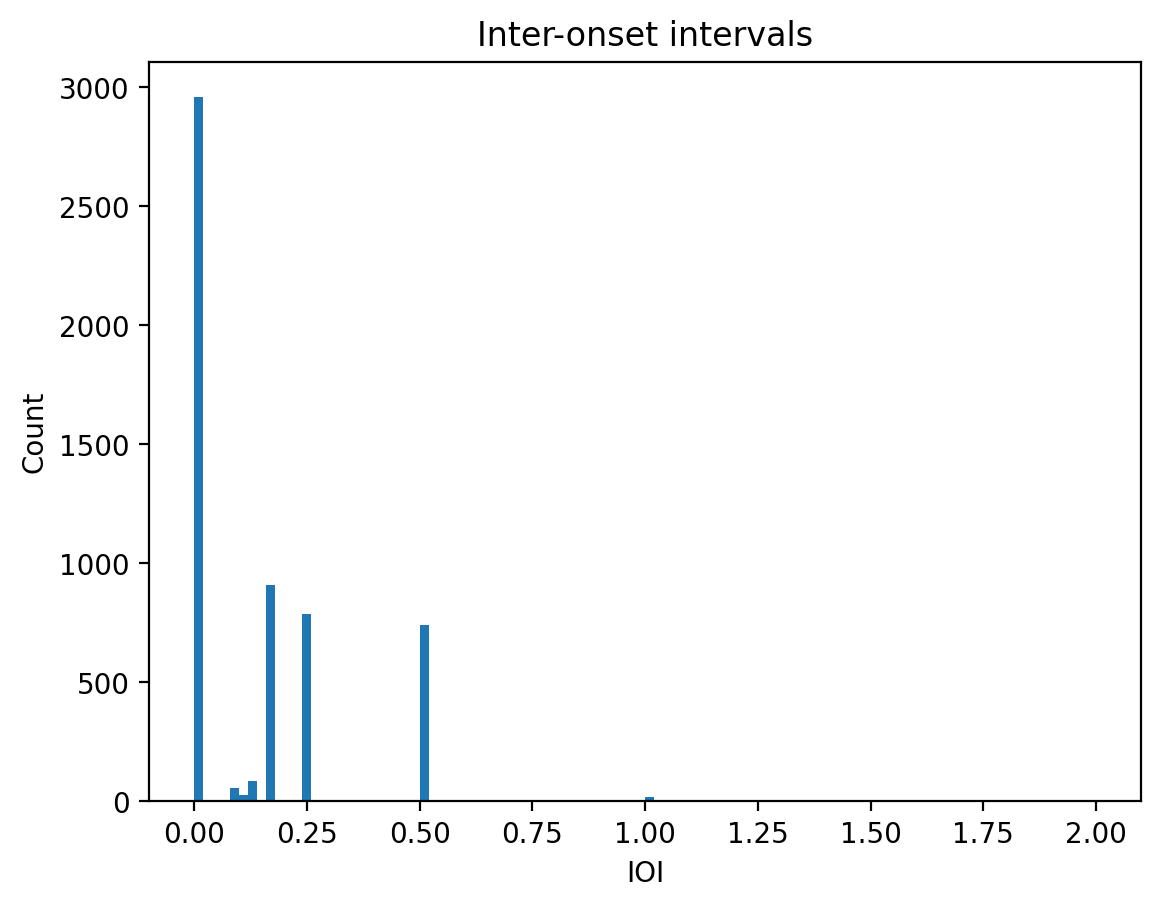

In [33]:
# 1. Get all the inter-onset intervals (IOIs) from the notes data and plot a histogram of the IOIs. (4 points)
# Hint: https://ms3.readthedocs.io/en/latest/manual/index.html#column-names
# 2nd hint: think of the type of your column, you might need to convert it to a different type before calculating the IOIs.

ioi = notes["quarterbeats"].diff().apply(float)

plt.hist(ioi, bins=100)
plt.xlabel("IOI")
plt.ylabel("Count")
plt.title("Inter-onset intervals")
plt.show()

#### 2. Why does the histogram show a lot of IOIs at 0 ? (2 points)
Because many of the notes are played at the same time (in unison). 

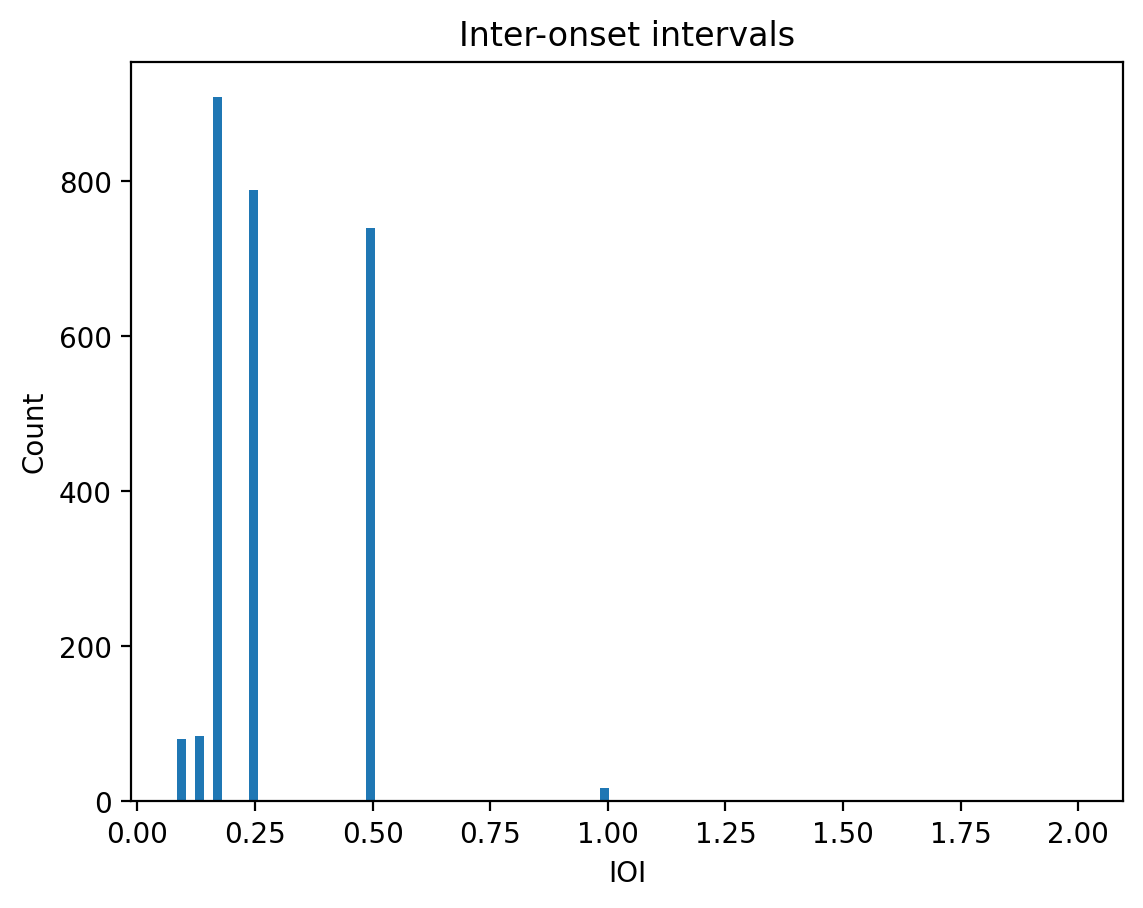

quarterbeats
0.083333     56
0.100000     25
0.125000     84
0.166667    908
0.250000    788
0.500000    740
1.000000     17
1.500000      2
2.000000      2
Name: quarterbeats, dtype: int64

In [34]:
# 3. Remove the IOIs that are equal to 0 and plot the histogram. (1 point)

ioi = ioi[ioi > 0]

plt.hist(ioi, bins=100)
plt.xlabel("IOI")
plt.ylabel("Count")
plt.title("Inter-onset intervals")
plt.show()

# 4. Print the frequency of the different IOIs (1 point)
ioi.groupby(ioi).count()

#### 5. Define what type of duration each IOI corresponds to (e.g., quarter note, half note, etc.) and explain how you can use this information to analyze the rhythm of the piece. (2 points)

0.083333 → 1/48 note 

0.100000 → 1/40 note 

0.125000 → 1/32 note

0.166667 → 1/24 note

0.250000 → sixteenth

0.500000 → eighth note

1.000000 → quarter note

1.500000 → dotted quarter note

2.000000 → half note

now each note has a rhythmic duration and can now see how the note onsets align with the metrical grid. In doing so, we can now statistically analyses musical onsets: most common onsets, patterns in onsets based on powers of 2, etc.

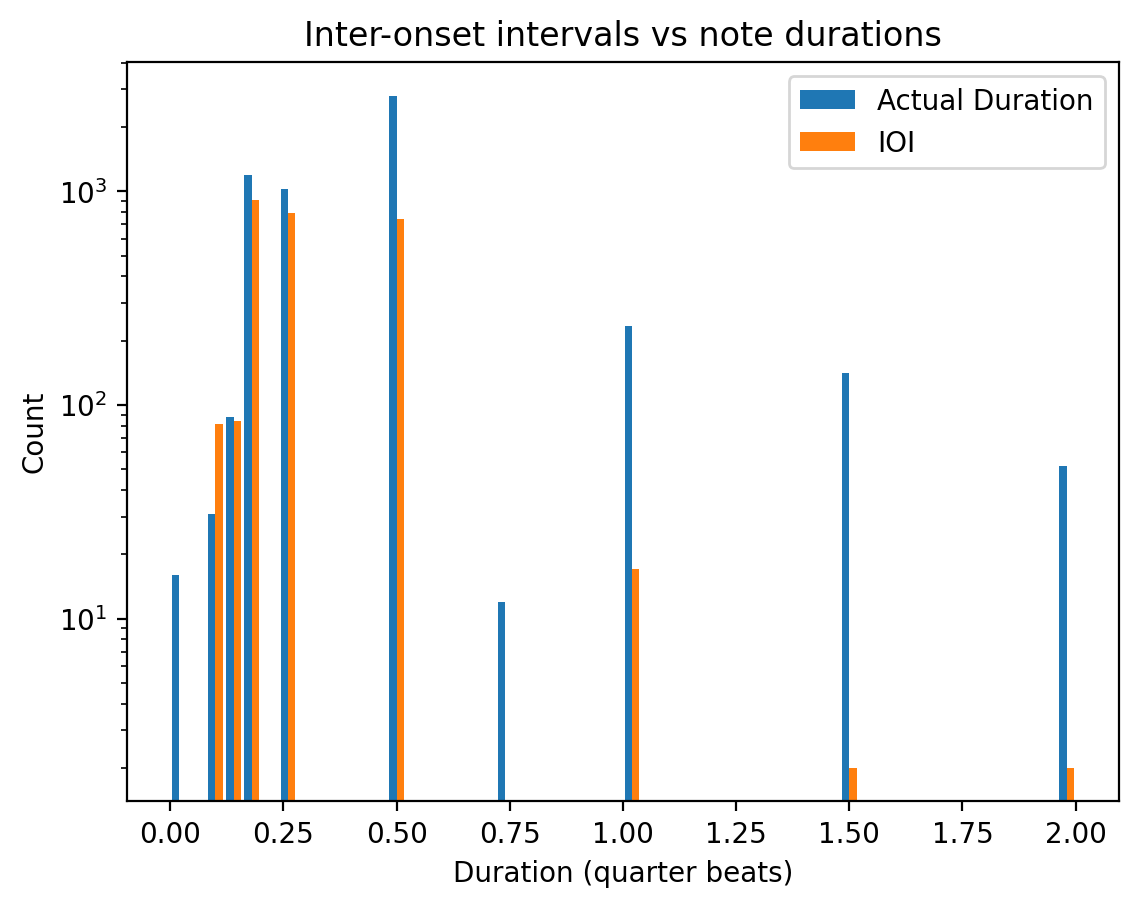

In [35]:
# 6. Verify if the IOIs correspond to the actual durations of the notes (3 points)

plt.hist((notes["duration_qb"], ioi), bins=50, label=["Actual Duration", "IOI"])

plt.xlabel("Duration (quarter beats)")
plt.ylabel("Count")
plt.yscale("log")
plt.title("Inter-onset intervals vs note durations")

plt.legend()
plt.show()

#### 7. What do you observe? Is there a difference and if yes why ? (2 points)

yes, there is a difference. Potential reasons: polyphony, moments of complete silence, chords/notes played starting at the same time.

In [36]:
# 8. Find the time signature of this movement (1 point)
# Hint you can prove it by code or from your observations of the dataframe (Not the score!)

notes["timesig"].unique()


<ArrowStringArray>
['2/4']
Length: 1, dtype: str

Tempo: 120 BPM
Time Signature: 4/4


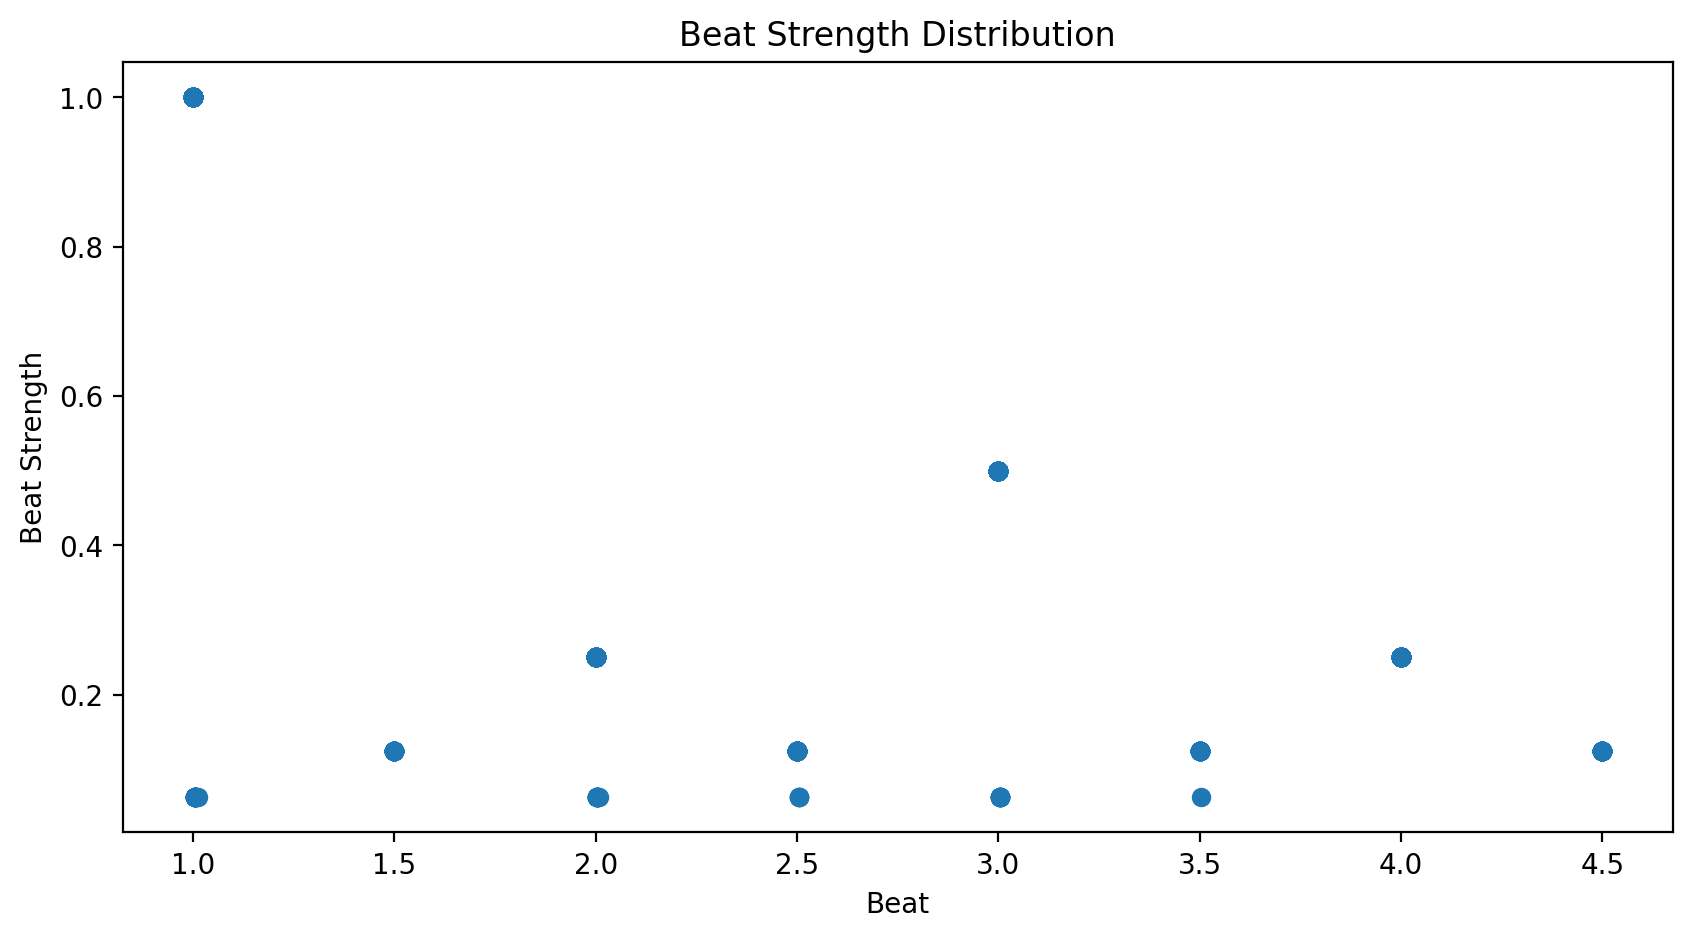

In [37]:
score = converter.parse("res/mei_score.mei")

# From this new score:

# 9. Find the tempo (1 point)
# Hint you can use the music21 library to find the tempo.
tempo = score.metronomeMarkBoundaries()[0][2].number
print("Tempo:", tempo, "BPM")

# 10. Find the time signature (1 point)
time_signature = score.recurse().getElementsByClass('TimeSignature')[0].ratioString
print("Time Signature:", time_signature)

# 11. Show the distribution of beat strengths in the piece, constricted to one bar. (3 points)
beats = []
beat_strengths = []

for n in score.recurse().notes:
    beats.append(n.beat)
    beat_strengths.append(n.beatStrength)
    
plt.figure(figsize=(10, 5))
plt.plot(beats, beat_strengths, 'o')
plt.title('Beat Strength Distribution')
plt.xlabel('Beat')
plt.ylabel('Beat Strength')
plt.show()

#### 12. Which concept from the lecture does the beat strength distribution correspond to? (1 point)

The metrical grid.

#### 13. Are there several beat strength values for a single beat position? If so, explain why? (2 points)

Some beat strengths are rounded and are played shortly after the acutal beat (not 1.0 but 1.00390625). We looked at the score and found that it is likely related to the trills.

## Part 2: Time function

As you have seen in the first lab, we can show that there is a difference between the performed MIDI file and the score MIDI file. In this part, we will analyze what is this difference without the cumulative effect.

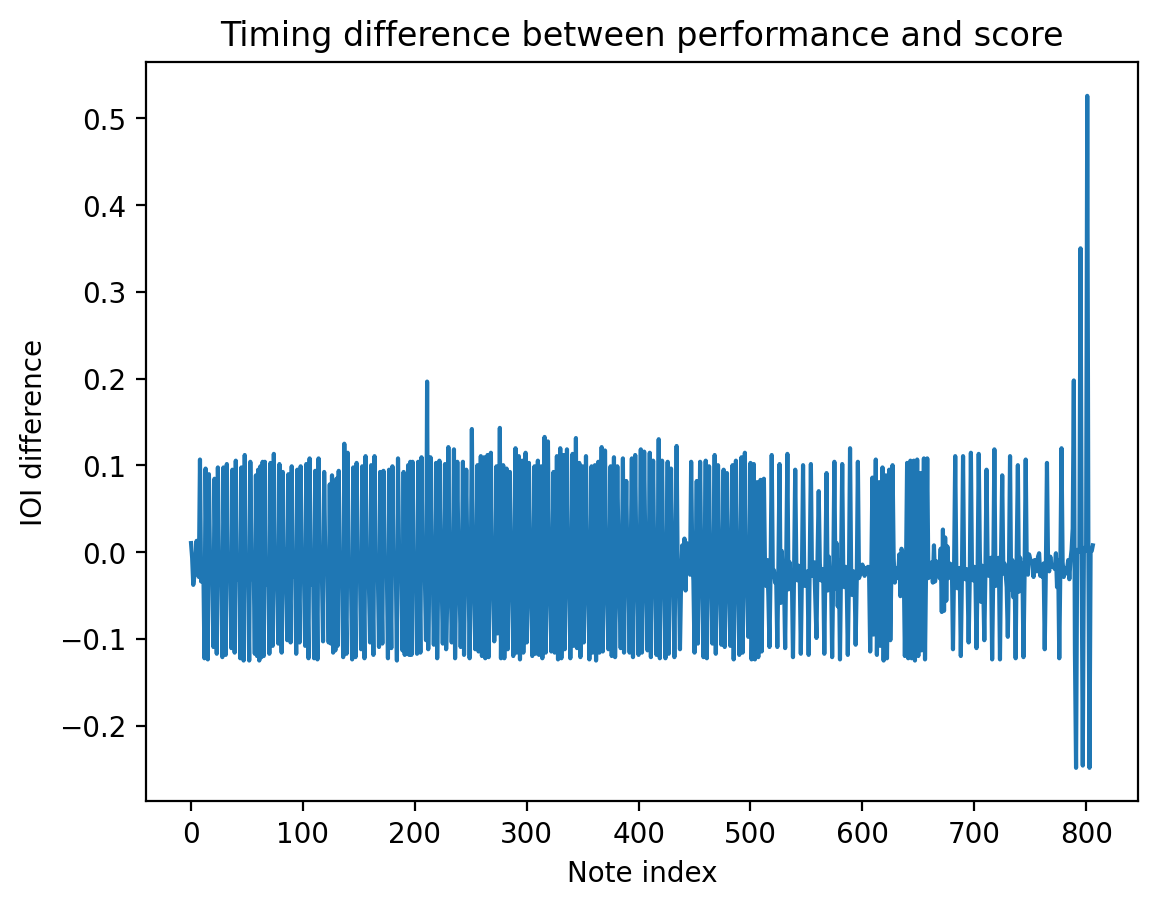

In [39]:
# 1. Show in a graph, the time difference between the performed MIDI file and the score MIDI file
# Instead of looking at each onset time, we will look at the inter-onset intervals (IOIs) and show the difference between the performed IOIs and the score IOIs. This will give us a better understanding of the timing differences between the two MIDI files. (4 points)

def get_note_on_times_seconds(midi_file: mido.MidiFile) -> list[float]:
    """
    Extract the times of note_on messages from a MIDI file in seconds.
    :param midi_file: mido.MidiFile: The MIDI file to extract note_on times from.
    :return: list[float]: A list of times (in seconds) of note_on messages.
    """
    ticks_per_beat = midi_file.ticks_per_beat
    tempo = 500000  # Default tempo in microseconds per beat
    ticks_times = []
    current_time = 0
    for msg in mido.merge_tracks(midi_file.tracks):
        current_time += msg.time
        if msg.type == 'note_on' and msg.velocity > 0:
            ticks_times.append(current_time)
            
    for track in midi_file.tracks:
        for msg in track:
            if msg.type == 'set_tempo':
                tempo = msg.tempo
                break
    return [(tick * tempo) / (ticks_per_beat * 1000000) for tick in ticks_times] 


performed_note_on_times = get_note_on_times_seconds(mido.MidiFile(performance_midi_file_path))
score_note_on_times = get_note_on_times_seconds(mido.MidiFile(midi_file_path))

min_len = min(len(performed_note_on_times), len(score_note_on_times))
ioi_diff = np.diff(performed_note_on_times[:min_len]) - np.diff(score_note_on_times[:min_len])

plt.plot(ioi_diff)
plt.xlabel("Note index")
plt.ylabel("IOI difference")
plt.title("Timing difference between performance and score")
plt.show()

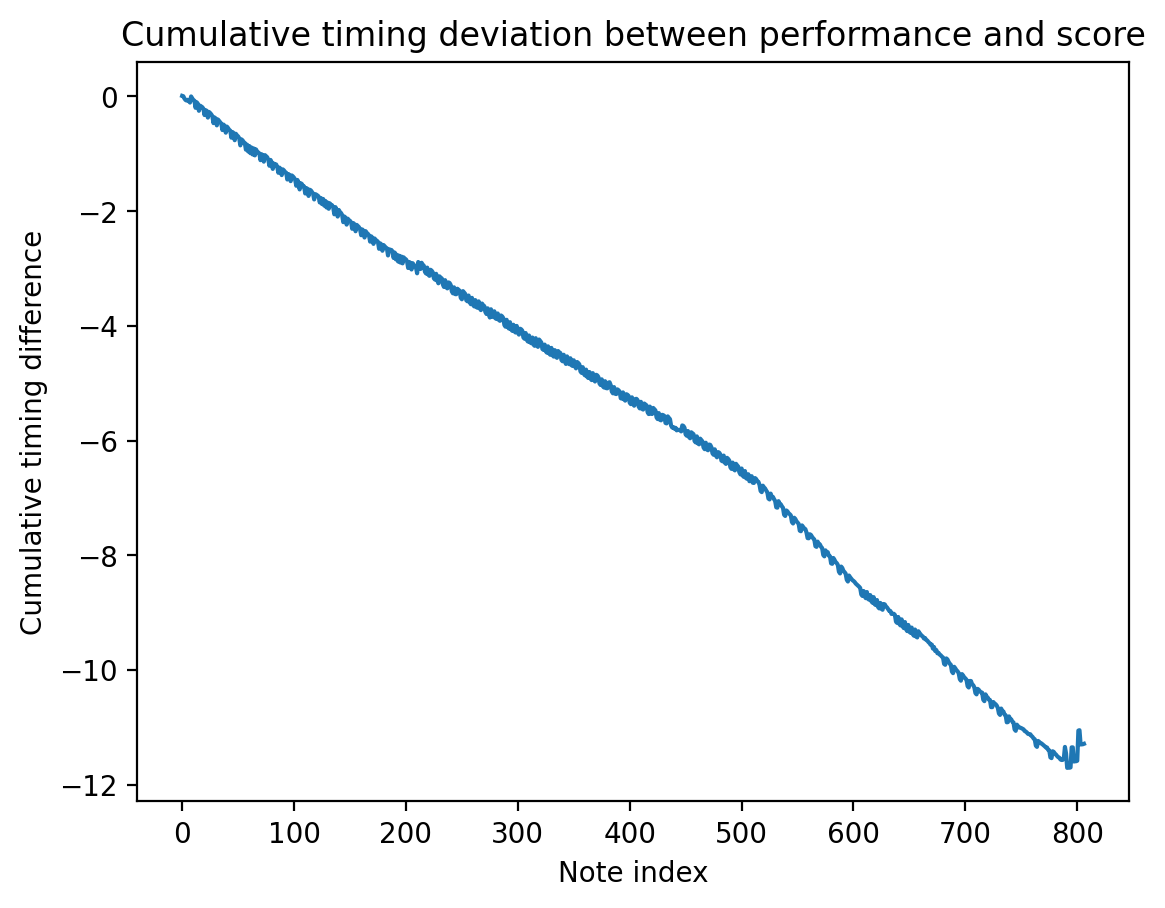

In [40]:
# 2. To verify your result, show the cumulative time differences between the performed MIDI file and the score MIDI file. 
# The result should be similar to the graph you showed in the first lab. (1 point)
# Use np.cumsum

cumulative_diff = np.cumsum(ioi_diff)
plt.plot(cumulative_diff)
plt.xlabel("Note index")
plt.ylabel("Cumulative timing difference")
plt.title("Cumulative timing deviation between performance and score")
plt.show()

#### 3. How can we use the time function to compare different performances of the same piece? (2 points)
We can use the timing funciton shows different in ioi times, so comparing two different performances shows their individual distortions in the metrical beat grid via rubato or microtimings.


#### 4. What factors would also be different between the performed MIDI file and the score MIDI file, besides timing? (2 points)
They would differ in dynamics, timber maybe, note durations (legato vs staccato), etc.

# The End

Starting from this lab, we will always propose some possible projects that you can work on for the final project. You can choose one of these projects or propose your own project related to rhythm analysis or generation. 

## Possible Projects 

- Beat Tracking
- Tempo Estimation
- Meter Detection
- Metrical Grid Estimation
- Performance Analysis
- Rhythm Generation
- Rhythm Transcription from MIDI
- Implement Rhythm Grammar (https://archives.ismir.net/ismir2020/paper/000368.pdf)